<a href="https://colab.research.google.com/github/aaryanML/Pytorch/blob/main/FashionMNIST_ANN_GPU_BatchNorm_Dropout_L2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn

## Download and Load Dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zalando-research/fashionmnist")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fashionmnist' dataset.
Path to dataset files: /kaggle/input/fashionmnist


In [4]:
dataset_path = '/kaggle/input/fashionmnist'

os.listdir(dataset_path)

['t10k-labels-idx1-ubyte',
 't10k-images-idx3-ubyte',
 'fashion-mnist_test.csv',
 'fashion-mnist_train.csv',
 'train-labels-idx1-ubyte',
 'train-images-idx3-ubyte']

In [5]:
train_df = pd.read_csv(dataset_path + '/fashion-mnist_train.csv')
test_df = pd.read_csv(dataset_path + '/fashion-mnist_test.csv')

In [15]:
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Basic Data Inspection

In [6]:
print(train_df.shape)
print(test_df.shape)

(60000, 785)
(10000, 785)


In [7]:
train_df.isna().sum().sum()
# no nan values

np.int64(0)

In [14]:
test_df.isna().sum().sum()

np.int64(0)

## Split Features and Labels

In [23]:
x_train = train_df.iloc[:,1:].values
y_train = train_df.iloc[:,0].values

x_test = test_df.iloc[:,1:].values
y_test = test_df.iloc[:,0].values

## Data Normalisation

In [29]:
# Scale pixel values from [0,255] to [0,1]
x_train = x_train / 255.0
x_test = x_test / 255.0

In [24]:
x_train.shape

(60000, 784)

## Visualise Sample Images

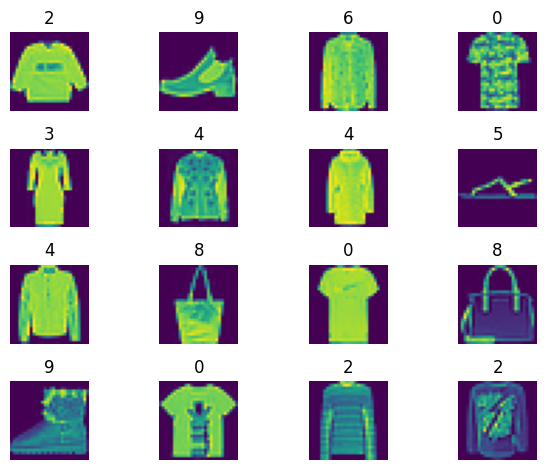

In [28]:
for i in range(16):
  plt.subplot(4,4,i+1)
  plt.imshow(x_train[i].reshape(28,28))
  plt.title(y_train[i])
  plt.axis('off')

plt.tight_layout()
plt.show()

## Device Configuration

In [10]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device : ', device)

device :  cuda


## Custom Dataset Class

In [11]:
class CustomDataset(Dataset):
  def __init__(self,features,labels):
    # Convert numpy arrays to PyTorch tensors
    self.features = torch.tensor(features,dtype=torch.float32)
    # Labels must be long integers for CrossEntropyLoss
    self.labels = torch.tensor(labels,dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self,index):
    return self.features[index],self.labels[index]

## Create Dataset and DataLoader Objects

In [51]:
train_dataset = CustomDataset(x_train,y_train)
test_dataset = CustomDataset(x_test,y_test)

In [52]:
# Load data in mini-batches

# Shuffle training data every epoch
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
# Keep test data order fixed
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

## Neural Network Architecture

In [80]:
class ANN(nn.Module):
  def __init__(self,num_features):
    super().__init__()
    self.network = nn.Sequential(
        # Hidden layer 1
        nn.Linear(num_features,128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(0.3),

        # Hidden layer 2
        nn.Linear(128,64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(0.3),

        # Output layer
        nn.Linear(64,10)
    )

  def forward(self,x):
    return self.network(x)

In [81]:
epochs = 25
learning_rate = 0.1

## Model, Loss Function and Optimiser

In [82]:
model = ANN(x_train.shape[1]).to(device)

optimizer = torch.optim.SGD(model.parameters(),lr=learning_rate,weight_decay=1e-4)

# Computes softmax internally, so no Softmax layer is needed
criterion = nn.CrossEntropyLoss()

## Model Training

In [83]:
for epoch in range(epochs):
  epoch_loss = 0

  for batch_features,batch_labels in train_loader:
    # Move batch to GPU/CPU
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)

    # Forward pass
    y_pred = model(batch_features)

    # Compute loss
    loss = criterion(y_pred,batch_labels)

    # Clear previous gradients
    optimizer.zero_grad()

    # Backpropagation
    loss.backward()

    # Update parameters
    optimizer.step()

    epoch_loss += loss.item()

  avg_loss = epoch_loss / len(train_loader)
  print(f'Epoch : {epoch+1} , Avg Epoch Loss : {avg_loss:.4f}')

Epoch : 1 , Avg Epoch Loss : 0.6038
Epoch : 2 , Avg Epoch Loss : 0.4780
Epoch : 3 , Avg Epoch Loss : 0.4472
Epoch : 4 , Avg Epoch Loss : 0.4190
Epoch : 5 , Avg Epoch Loss : 0.4080
Epoch : 6 , Avg Epoch Loss : 0.3984
Epoch : 7 , Avg Epoch Loss : 0.3861
Epoch : 8 , Avg Epoch Loss : 0.3803
Epoch : 9 , Avg Epoch Loss : 0.3687
Epoch : 10 , Avg Epoch Loss : 0.3612
Epoch : 11 , Avg Epoch Loss : 0.3619
Epoch : 12 , Avg Epoch Loss : 0.3517
Epoch : 13 , Avg Epoch Loss : 0.3485
Epoch : 14 , Avg Epoch Loss : 0.3452
Epoch : 15 , Avg Epoch Loss : 0.3423
Epoch : 16 , Avg Epoch Loss : 0.3409
Epoch : 17 , Avg Epoch Loss : 0.3371
Epoch : 18 , Avg Epoch Loss : 0.3361
Epoch : 19 , Avg Epoch Loss : 0.3333
Epoch : 20 , Avg Epoch Loss : 0.3275
Epoch : 21 , Avg Epoch Loss : 0.3241
Epoch : 22 , Avg Epoch Loss : 0.3228
Epoch : 23 , Avg Epoch Loss : 0.3222
Epoch : 24 , Avg Epoch Loss : 0.3204
Epoch : 25 , Avg Epoch Loss : 0.3206


## Test Set Evaluation

In [84]:
model.eval()

ANN(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [85]:
correct = 0
total = 0

with torch.no_grad():
  for batch_features,batch_labels in test_loader:
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)

    y_pred = model(batch_features)
    y_pred = torch.argmax(y_pred,dim=1)

    correct += (y_pred == batch_labels).sum()
    total += len(batch_labels)

  print(f'test Accuracy : {correct / total}')

test Accuracy : 0.8886999487876892


## Train Set Evaluation

In [86]:
correct = 0
total = 0

with torch.no_grad():
  for batch_features,batch_labels in train_loader:
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)

    y_pred = model(batch_features)
    y_pred = torch.argmax(y_pred,dim=1)

    correct += (y_pred == batch_labels).sum()
    total += len(batch_labels)

  print(f'train Accuracy : {correct / total}')

train Accuracy : 0.9197999835014343
